# Memory & Threads in Conversational Agentic AI Systems in LangGraph

Every interaction between the user and the agentic system is in isolation and a new request without keep track of past historical conversations (by default). By leveraging memory and threads we can make our agentic system conversational.

![](https://i.imgur.com/nJn1o09.png)

#### Memory in LangGraph:

- Utilizes a built-in persistence layer to maintain graph state across executions.
- Enables features like human-in-the-loop interactions, time travel, fault tolerance and conversational capabilities

#### Threads:

- Serve as unique identifiers for sequences of checkpoints (agent state snapshots).
- Allow retrieval and management of graph states post-execution.
- Specified during graph invocation via {"configurable": {"thread_id": "user-session-id"}}.
- User session id can be generated and assigned per unique user or user session
- This is used by the agent to refer to past conversation and agent state history for any user session at any time
- Enables multi-user conversation for your agent


In [1]:
!pip install langchain==0.3.14
!pip install langchain-openai==0.3.0
!pip install langchain-community==0.3.14
!pip install langgraph==0.2.64
!pip install langgraph-checkpoint-sqlite==2.0.3

## Enter Open AI API Key

In [2]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

## Enter Tavily Search API Key

Get a free API key from [here](https://tavily.com/#api)

In [3]:
TAVILY_API_KEY = getpass('Enter Tavily Search API Key: ')

## Setup Environment Variables

In [4]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY
os.environ['TAVILY_API_KEY'] = TAVILY_API_KEY

## State

First, define the [State](https://langchain-ai.github.io/langgraph/concepts/low_level/#state) of the graph.

The State schema serves as the input schema for all Nodes and Edges in the graph.

Let's use the `TypedDict` class from python's `typing` module as our schema, which provides type hints for the keys.

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

## Augment the LLM with tools

Here we define our custom search tool and then bind it to the LLM to augment the LLM

In [6]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langchain_core.tools import tool

llm = ChatOpenAI(model="gpt-4o", temperature=0)

tavily_search = TavilySearchAPIWrapper()
@tool
def search_web(query: str, num_results=5):
    """Search the web for a query. Userful for general information or general news"""
    results = tavily_search.raw_results(query=query,
                                        max_results=num_results,
                                        search_depth='advanced',
                                        include_raw_content=True)
    return results

tools = [search_web]
llm_with_tools = llm.bind_tools(tools=tools)

## Build Agentic Graph with In-Memory Persistence

In [7]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver


# Augmented LLM with Tools Node function
def tool_calling_llm(state: State) -> State:
    current_state = state["messages"]
    return {"messages": [llm_with_tools.invoke(current_state)]}

# Build the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))
builder.add_edge(START, "tool_calling_llm")

# Conditional Edge
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from LLM is a tool call -> tools_condition routes to tools
    # If the latest message (result) from LLM is a not a tool call -> tools_condition routes to END
    tools_condition,
    ["tools", END]
)
builder.add_edge("tools", "tool_calling_llm") # this is the key feedback loop
builder.add_edge("tools", END)

# add in-memory persistence (transient memory)
memory = MemorySaver()
agent_inmem = builder.compile(checkpointer=memory)

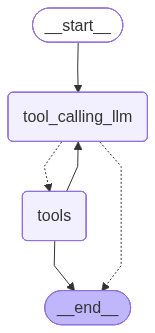

In [8]:
agent_inmem

## Test Agent with In-Memory Persistence

In [9]:
uid = 'user001'
config = {"configurable": {"thread_id": uid}}

In [10]:
user_input = "Explain AI in 1 line"
for event in agent_inmem.stream(input={"messages": user_input},
                          config=config,
                          stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Explain AI in 1 line
================================== Ai Message ==================================

AI, or Artificial Intelligence, is the simulation of human intelligence processes by machines, especially computer systems, to perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation.


In [11]:
user_input = "Do the same for ML"
for event in agent_inmem.stream(input={"messages": user_input},
                          config=config,
                          stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Do the same for ML
================================== Ai Message ==================================

Machine Learning (ML) is a subset of AI that involves the use of algorithms and statistical models to enable computers to learn from and make predictions or decisions based on data without being explicitly programmed.


In [12]:
agent_inmem.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='Explain AI in 1 line', additional_kwargs={}, response_metadata={}, id='a2aa9068-4c73-443b-8e1f-1aaac5e37bfa'), AIMessage(content='AI, or Artificial Intelligence, is the simulation of human intelligence processes by machines, especially computer systems, to perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 71, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_b1442291a8', 'finish_reason': 'stop', 'logprobs': None}, id='run--b03ef1eb-b2ce-47db-bd23-c9fdc57b312a-0', usage_metadata={'input_t

In [13]:
history = list(agent_inmem.get_state_history(config))
history

[StateSnapshot(values={'messages': [HumanMessage(content='Explain AI in 1 line', additional_kwargs={}, response_metadata={}, id='a2aa9068-4c73-443b-8e1f-1aaac5e37bfa'), AIMessage(content='AI, or Artificial Intelligence, is the simulation of human intelligence processes by machines, especially computer systems, to perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 71, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_b1442291a8', 'finish_reason': 'stop', 'logprobs': None}, id='run--b03ef1eb-b2ce-47db-bd23-c9fdc57b312a-0', usage_metadata={'input_

In [14]:
uid = 'user002'
config = {"configurable": {"thread_id": uid}}

In [15]:
user_input = "Tell me 3 latest OpenAI product releases"
for event in agent_inmem.stream(input={"messages": user_input},
                          config=config,
                          stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Tell me 3 latest OpenAI product releases
================================== Ai Message ==================================
Tool Calls:
  search_web (call_Bzf8rVFewuTnK48uaEoyRU5G)
 Call ID: call_Bzf8rVFewuTnK48uaEoyRU5G
  Args:
    query: latest OpenAI product releases
    num_results: 3
================================= Tool Message =================================
Name: search_web

{"query": "latest OpenAI product releases", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://help.openai.com/en/articles/6825453-chatgpt-release-notes", "title": "ChatGPT — Release Notes - OpenAI Help Center", "content": "Today, we’re releasing OpenAI o3 and o4-mini, the latest in our o-series of models trained to think for longer before responding. These are the smartest models we’ve released to date, representing a step change in ChatGPT's capabilities for everyone from curious users t

In [16]:
user_input = "do the same for Meta releases"
for event in agent_inmem.stream(input={"messages": user_input},
                          config=config,
                          stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

do the same for Meta releases
================================== Ai Message ==================================
Tool Calls:
  search_web (call_ed7YUpHBv4beyR7E4wxYtHBe)
 Call ID: call_ed7YUpHBv4beyR7E4wxYtHBe
  Args:
    query: latest Meta product releases
    num_results: 3
================================= Tool Message =================================
Name: search_web

{"query": "latest Meta product releases", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.meta.com/blog/connect-2025-day-one-keynote-ai-glasses-ray-ban-display-neural-band-metaverse-news/?srsltid=AfmBOorGmhq3H3-_0VomEopa8TYc8Af5djpgyQ2ssgICVFVed3Ue_Grn", "title": "Meta Connect 2025: The Evolution of AI Glasses, Metaverse ...", "content": "Image 25 Save the Date: Meta Connect 2025 & Our Inaugural LlamaCon Feb 18, 2025 Last year was an eventful one with the introduction of Meta Horizon OS, the lau

In [17]:
uid = 'user001'
config = {"configurable": {"thread_id": uid}}
user_input = "what did we discuss so far"
for event in agent_inmem.stream(input={"messages": user_input},
                          config=config,
                          stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

what did we discuss so far
================================== Ai Message ==================================

We discussed brief one-line explanations of Artificial Intelligence (AI) and Machine Learning (ML). AI was described as the simulation of human intelligence processes by machines, while ML was defined as a subset of AI that enables computers to learn from data and make predictions or decisions without explicit programming.


## Build & Test Agentic Graph with On-disk Persistence

In [18]:
# clearing memory database (just for demo, in general should keep it)
!rm memory.db*

zsh:1: no matches found: memory.db*


In [19]:
from langgraph.checkpoint.sqlite import SqliteSaver

def call_conversational_agent(agent_graph, prompt, user_session_id):
    with SqliteSaver.from_conn_string("memory.db") as memory:
        agent_extmem = agent_graph.compile(checkpointer=memory)
        for event in agent_extmem.stream(input={"messages": prompt},
                                         config={"configurable": {"thread_id": user_session_id}},
                                         stream_mode='values'):
            event['messages'][-1].pretty_print()

In [20]:
builder

In [21]:
uid = 'bond007'
prompt = "What is the latest news on Apple? summarize in 3 bullets"
call_conversational_agent(agent_graph=builder,
                          prompt=prompt,
                          user_session_id=uid)

================================ Human Message =================================

What is the latest news on Apple? summarize in 3 bullets
================================== Ai Message ==================================
Tool Calls:
  search_web (call_SucpYaXzWilgNk3cr5ZO72jF)
 Call ID: call_SucpYaXzWilgNk3cr5ZO72jF
  Args:
    query: latest news on Apple
    num_results: 3
================================= Tool Message =================================
Name: search_web

{"query": "latest news on Apple", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.apple.com/newsroom/2025/11/introducing-iphone-pocket-a-beautiful-way-to-wear-and-carry-iphone/", "title": "Introducing iPhone Pocket: a beautiful way to wear and carry iPhone", "content": "Apple Newsroom The latest news and updates, direct from Apple. Read more\n\n Stay up to date with the latest articles from Apple Newsroom. \n\n Dismiss  Get Notifications \n\nApple Footer\n\nApple\n\n1.   News

In [22]:
prompt = "What about microsoft?"
call_conversational_agent(agent_graph=builder,
                          prompt=prompt,
                          user_session_id=uid)

================================ Human Message =================================

What about microsoft?
================================== Ai Message ==================================
Tool Calls:
  search_web (call_JTJjdGz0Klp6eBHziXCBTgQ8)
 Call ID: call_JTJjdGz0Klp6eBHziXCBTgQ8
  Args:
    query: latest news on Microsoft
    num_results: 3
================================= Tool Message =================================
Name: search_web

{"query": "latest news on Microsoft", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://news.microsoft.com/recent-news/", "title": "Recent News - Stories - Microsoft Source", "content": "Search Search news.microsoft.com/source\n\n   No results\n\nCancel0 Cart 0 items in shopping cart\n\nRecent News\n\n May 6, 2025 \n\nMicrosoft and FFA help students use smart sensors and AI to learn about the future of farming and technology\n\n April 30, 2025 \n\nMicrosoft earnings press release available on Investor Relations w